Código adaptado de:

[1] D. Foster, Generative Deep Learning: Teaching Machines to Paint, Write, Compose, and Play, Second Edition, O'Reilly, 2023.

[2] A. Nandan, Text generation with a miniature GPT, disponível no site do Keras [(link)](https://keras.io/examples/generative/text_generation_with_miniature_gpt/).

# Bibliotecas

In [1]:
!pip install torchinfo

In [2]:
import os                                         # módulo para interagir com o sistema de arquivos (criar pastas, ler arquivos, etc.)
import json                                       # leitura e escrita de dados em formato JSON
import re                                         # expressões regulares para limpeza e padronização de texto
import string                                     # utilitários para operações com strings (e.g., lista de pontuações)
import numpy as np                                # biblioteca para cálculo numérico e operações com arrays
import torch                                      # PyTorch: framework de aprendizado profundo
import torch.nn as nn                             # módulos de construção de redes neurais (camadas, funções de perda, etc.)
from torch.utils.data import Dataset, DataLoader  # abstrações para conjuntos de dados e carregamento de dados
from torch.utils.data import random_split         # utilitário para dividir um Dataset em subconjuntos (ex.: treinamento/teste)
import torch.nn.functional as F                   # funções de ativação, perda e utilitários funcionais
from torchinfo import summary                     # para exibir o resumo da arquitetura do modelo em PyTorch
import tensorflow as tf                           # importa o TensorFlow (usado aqui principalmente para TextVectorization e pré-processamento)
from tensorflow.keras import layers               # importa o submódulo de camadas do Keras (usado aqui para acesso direto às camadas Keras (ex.: layers.TextVectorization))
import gdown                                      # download de arquivos públicos do Google Drive
from IPython.display import display, HTML         # renderização no notebook (exibir strings/HTML formatado)
from tqdm.auto import tqdm                        # barras de progresso adaptáveis ao ambiente
from typing import Tuple                          # anotações de tipo
import matplotlib.pyplot as plt                   # criação de gráficos

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
print(f'Versão do pytorch: {torch.__version__}.')  # exibe a versão instalada do PyTorch

Versão do pytorch: 2.7.1+cu128.


In [4]:
# Configurações do Jupyter/Colab:
%matplotlib inline

# Hiperparâmetros

In [5]:
# Hiper-parâmetros principais
VOCAB_SIZE       = 10_000  # @param {type:"integer"}  # tamanho máximo do vocabulário aprendido pela tokenização
MAX_LEN          = 80      # @param {type:"integer"}  # comprimento base da sequência; no Dataset vira MAX_LEN + 1 para criar "x[:-1]" e "y[1:]"
EMBEDDING_DIM    = 256     # @param {type:"integer"}  # dimensão dos embeddings de token e de posição
KEY_DIM          = 256     # @param {type:"integer"}  # dimensão interna planejada para Q/K
N_HEADS          = 2       # @param {type:"integer"}  # número de cabeças de atenção
FEED_FORWARD_DIM = 256     # @param {type:"integer"}  # dimensão do MLP interno do bloco Transformador
SEED             = 42      # @param {type:"integer"}  # semente para reprodutibilidade
BATCH_SIZE       = 32      # @param {type:"integer"}  # número de sequências por lote no DataLoader
EPOCHS           = 10       # @param {type:"integer"}  # número de épocas de treinamento
LEARNING_RATE    = 3e-4    # @param {type:"number"}   # taxa de aprendizado

DEVICE = (                                            # escolhe o dispositivo de treino: acelerador disponível via torch.accelerator ou CPU
    torch.accelerator.current_accelerator().type      # obtém o tipo do acelerador atual (ex.: "cuda", "mps")
    if torch.accelerator.is_available()               # verifica se há algum acelerador disponível
    else "cpu"                                        # fallback seguro para CPU
)

# 1. Carregar os dados [Epicurious - Recipes with Rating and Nutrition](https://www.kaggle.com/datasets/hugodarwood/epirecipes)

In [6]:
url = 'https://drive.google.com/file/d/1gzDjjou1lbCU87H_rDg5mhAJlkqTTqgn/view?usp=sharing'  # URL pública do arquivo no Google Drive
output = 'full_format_recipes.json'                                                         # nome do arquivo local onde o JSON será salvo
quiet = False                                                                               # controla a verbosidade do gdown (False = mostra progresso/mensagens)
fuzzy = True                                                                                # permite que o gdown interprete diferentes formatos de URL do Drive
if not os.path.exists(output):                                                              # verifica se o arquivo já existe no diretório atual
    gdown.download(url=url, output=output, quiet=quiet, fuzzy=True)                         # Se não existir, baixa o arquivo do Drive usando as opções definidas acima
else:
    print(f"O arquivo '{output}' já está presente. Nenhum download foi realizado.")         # evita download repetido e informa o usuário

Downloading...
From: https://drive.google.com/uc?id=1gzDjjou1lbCU87H_rDg5mhAJlkqTTqgn
To: d:\Github\GenAI\14 - Transformers\full_format_recipes.json
100%|██████████| 35.2M/35.2M [00:03<00:00, 11.3MB/s]


In [8]:
with open("./full_format_recipes.json") as json_data:           # abre o arquivo JSON de receitas em modo leitura
    data = json.load(json_data)                          # carrega o conteúdo do arquivo como uma lista de dicionários
print(f'tipo de data: {type(data)}')              # mostra o tipo da variável data (list)
print(f'tipo de data[indice]: {type(data[0])}')   # mostra o tipo de um elemento de data (dict)

tipo de data: <class 'list'>
tipo de data[indice]: <class 'dict'>


In [9]:
# Inspeção rápida dos dados
print(f'data: {type(data)}')                       # exibe o tipo do objeto carregado (esperado: list)
print(f'data[0]: {type(data[0])}')                 # exibe o tipo do primeiro elemento (esperado: dict)

# Percorre as chaves e valores do primeiro item do dicionário
for k, v in data[0].items():                       # itera pelos pares (chave, valor) da primeira resenha
    print(f'\t{k}: {v}')                           # imprime cada campo para entender a estrutura do conjunto de dados

data: <class 'list'>
data[0]: <class 'dict'>
	directions: ['1. Place the stock, lentils, celery, carrot, thyme, and salt in a medium saucepan and bring to a boil. Reduce heat to low and simmer until the lentils are tender, about 30 minutes, depending on the lentils. (If they begin to dry out, add water as needed.) Remove and discard the thyme. Drain and transfer the mixture to a bowl; let cool.', '2. Fold in the tomato, apple, lemon juice, and olive oil. Season with the pepper.', '3. To assemble a wrap, place 1 lavash sheet on a clean work surface. Spread some of the lentil mixture on the end nearest you, leaving a 1-inch border. Top with several slices of turkey, then some of the lettuce. Roll up the lavash, slice crosswise, and serve. If using tortillas, spread the lentils in the center, top with the turkey and lettuce, and fold up the bottom, left side, and right side before rolling away from you.']
	fat: 7.0
	date: 2006-09-01T04:00:00.000Z
	categories: ['Sandwich', 'Bean', 'Fruit',

# 2. Filtrar os dados

In [10]:
# Filtragem
filtered_data = [                                                   # lista de strings (uma por receita) que será usada como corpus de texto
    "Recipe for " + x["title"] + " | " + " ".join(x["directions"])  # monta um texto único: título + '|' + instruções concatenadas
    for x in data                                            # percorre cada dicionário de receita carregado do JSON original
    if "title" in x                                                 # garante que a chave "title" existe no dicionário
    and x["title"] is not None                                      # garante que o título não é nulo
    and "directions" in x                                           # garante que a chave "directions" existe no dicionário
    and x["directions"] is not None                                 # garante que as instruções não são nulas
]

In [11]:
n_recipes = len(filtered_data)                 # conta quantas receitas válidas foram filtradas para o corpus
print(f"{n_recipes} receitas carregadas.")     # exibe na tela o número total de receitas carregadas

20111 receitas carregadas.


In [12]:
# Exibição de exemplos
example = filtered_data[25]             # Pega a 26a resenha (índice 25) de exemplo
display(example)                        # Imprime essa resenha para inspeção rápida

'Recipe for Garlic Baguette Crumbs  | Mince garlic and mash to a paste with a pinch of salt, then transfer to a bowl and stir in oil, salt, and pepper. Add baguette crumbs and stir until combined well.'

# 3. Tokenização

In [13]:
# Pré-processamento: inserir espaços ao redor da pontuação
def pad_punctuation(s):                                       # Define a função que processa a pontuação
    s = re.sub(                                               # 1a substituição com expressão regular
        pattern=f"([{string.punctuation}, '\n'])",            #   • Captura qualquer caractere de pontuação ou quebra de linha
        repl=r" \1 ",                                         #   • Adiciona um espaço antes e outro depois do caractere capturado
        string=s                                              #   • string de entrada a ser transformada
    )
    s = re.sub(                                               # 2a substituição com expressão regular
        pattern=" +",                                         #   • Identifica sequências de múltiplos espaços
        repl=" ",                                             #   • Substitui por um único espaço
        string=s                                              #   • string de entrada a ser transformada
    )
    return s                                                  # Retorna a string processada

In [14]:
# Aplica a função de pré-processamento a cada resenha previamente filtrada
text_data = [pad_punctuation(x) for x in filtered_data]       # Cria nova lista com pontuação espaçada

In [15]:
# Visualização de um exemplo
example_data = text_data[25]                                  # Seleciona a 26a resenha para inspeção
display(example_data)                                         # Exibe o resultado

'Recipe for Garlic Baguette Crumbs | Mince garlic and mash to a paste with a pinch of salt , then transfer to a bowl and stir in oil , salt , and pepper . Add baguette crumbs and stir until combined well . '

# 4. Classe que encapsula os dados

In [16]:
class WineDataset(Dataset):
    """
    Dataset PyTorch para modelagem autoregressiva usando tokenização do Keras.

    Este dataset:
    1. Cria e adapta uma camada `TextVectorization` ao texto bruto.
    2. Vetoriza todas as sequências com padding/truncamento fixo.
    3. Constrói pares (x, y) por deslocamento de 1 token:
       - x = sequência sem o último token
       - y = sequência sem o primeiro token
    4. Retorna tensores PyTorch prontos para treinar um modelo do tipo decoder-only.

    Parameters
    ----------
    texto : list[str]
        Lista de strings contendo o corpus já filtrado.
    max_tokens : int, optional
        Tamanho máximo do vocabulário a ser aprendido pela `TextVectorization`.
        Default: VOCAB_SIZE.
    output_sequence_length : int, optional
        Comprimento fixo da sequência gerada pela vetorização.
        Tipicamente deve ser MAX_LEN + 1 para permitir o deslocamento que gera x e y de tamanho MAX_LEN.
        Default: MAX_LEN + 1.

    Attributes
    ----------
    vectorize_layer : tf.keras.layers.TextVectorization
        Camada responsável por aprender o vocabulário e converter texto em sequências de índices.
    x : torch.Tensor
        Tensores de entrada com shape (N, MAX_LEN), contendo tokens de 0 até o penúltimo.
    y : torch.Tensor
        Tensores-alvo com shape (N, MAX_LEN), contendo tokens do segundo até o último.

    Notes
    -----
    O índice 0 corresponde ao token de padding e o índice 1 ao token "[UNK]".
    """

    def __init__(
        self,
        texto: list[str],
        max_tokens: int = VOCAB_SIZE,
        output_sequence_length: int = MAX_LEN + 1
    ) -> None:
        # cria a camada de vetorização: minúsculas + vocabulário limitado + saída inteira + comprimento fixo
        self.vectorize_layer = layers.TextVectorization(    # Instancia TextVectorization
            standardize="lower",                            # padroniza texto convertendo para minúsculas
            max_tokens=max_tokens,                          # limita o vocabulário aos "max_tokens" tokens mais frequentes
            output_mode="int",                              # retorna sequência de índices inteiros
            output_sequence_length=output_sequence_length,  # comprimento fixo da sequência: MAX_LEN + 1 (padding/truncamento)
        )

        self.vectorize_layer.adapt(texto)                   # aprende o vocabulário percorrendo todo o corpus

        # vetoriza todo o texto (transforma em valores numéricos)): TF -> NumPy -> Torch, shape esperado (N, MAX_LEN + 1)
        tokenized_sentences = torch.from_numpy(self.vectorize_layer(texto).numpy().astype(np.int64)).long()

        # separa entrada (x) e alvo (y) por deslocamento de 1 token
        self.x: torch.Tensor = tokenized_sentences[:, :-1]  # entradas (x = sequência sem o último token): remove o último token -> (N, MAX_LEN)
        self.y: torch.Tensor = tokenized_sentences[:, 1:]   # alvos  (y = sequência sem o primeiro token): remove o primeiro token -> (N, MAX_LEN)

    # ----------------------------------------------------------------
    # Métodos obrigatórios do `torch.utils.data.Dataset`
    # ----------------------------------------------------------------
    def __len__(self) -> int:
        return self.x.shape[0]                              # retorna N, o número total de sequências

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.x[idx], self.y[idx]                     # retorna (x, y) como (entrada_tokenizada, alvo_tokenizado)

In [17]:
# Instancia o Dataset e o DataLoader

# cria o dataset a partir da lista de strings
dataset = WineDataset(texto=text_data)

N = len(dataset)                                           # número total de exemplos disponíveis no dataset completo
N_train = int(0.9 * N)                                     # define 90% dos exemplos para o conjunto de treinamento
N_test  = N - N_train                                      # define os 10% restantes para o conjunto de teste

train_ds, test_ds = random_split(
    dataset,
    [N_train, N_test],                                     # tamanhos desejados para os subconjuntos (treinamento e teste)
    generator=torch.Generator().manual_seed(42)            # fixa a semente para obter sempre o mesmo split (reprodutibilidade)
)

In [18]:
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)    # DataLoader de treinamento: agrupa exemplos em lotes e embaralha a cada época
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)  # DataLoader de teste: agrupa exemplos em lotes, mantendo a ordem fixa

In [19]:
print(f"N total:  {N}")
print(f"N treinamento: {len(train_ds)}")
print(f"N teste:  {len(test_ds)}")

N total:  20111
N treinamento: 18099
N teste:  2012


In [20]:
dataset.x[25]  # x tokenizado

tensor([  26,   16,   81, 1387,  492,   27, 1050,   81,    4,  572,    5,    9,
         345,    8,    9,  602,   14,   24,    3,   46,   40,    5,    9,   21,
           4,   42,    6,   37,    3,   24,    3,    4,   33,    2,   18, 1387,
         492,    4,   42,   10,  348,  128,    2,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

In [21]:
dataset.y[25]  # y tokenizado

tensor([  16,   81, 1387,  492,   27, 1050,   81,    4,  572,    5,    9,  345,
           8,    9,  602,   14,   24,    3,   46,   40,    5,    9,   21,    4,
          42,    6,   37,    3,   24,    3,    4,   33,    2,   18, 1387,  492,
           4,   42,   10,  348,  128,    2,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])

In [22]:
print(f'Número de exemplos do conjunto de dados: {len(dataset)}')  # exibe N (quantidade total de sequências tokenizadas no dataset)

Número de exemplos do conjunto de dados: 20111


In [23]:
vocab = dataset.vectorize_layer.get_vocabulary()  # vocabulário: lista de tokens do vocabulário aprendido pela TextVectorization (índice -> token)
print(f'vocab: {type(vocab)}')                    # confirma o tipo do vocabulário (esperado: list)
print(f'vocab[0]: {type(vocab[0])}')              # confirma o tipo de cada item (esperado: str)

vocab: <class 'list'>
vocab[0]: <class 'str'>


In [24]:
# Visualiza algumas correspondências "índice: palavra"
for i, word in enumerate(vocab[:10]):         # Percorre os 10 primeiros itens do vocabulário
    print(f"{i}: {word}")                     # Imprime "índice: palavra" no console

0: 
1: [UNK]
2: .
3: ,
4: and
5: to
6: in
7: the
8: with
9: a


# 5. Modelo

## Camadas de embedding (token e positional)

In [25]:
class TokenAndPositionEmbedding(nn.Module):
    """
    Camada que combina embedding de tokens e embedding posicional por soma.

    A soma exige que os embeddings de token e posição tenham a mesma dimensão.

    Parameters
    ----------
    max_len : int
        Comprimento máximo das sequências / número máximo de posições representáveis.
    vocab_size : int
        Tamanho do vocabulário (número máximo de tokens distintos).
    embed_dim : int
        Dimensão dos vetores de embedding para tokens e posições.

    Attributes
    ----------
    max_len : int
        Armazena o comprimento máximo da sequência.
    vocab_size : int
        Armazena o tamanho do vocabulário.
    embed_dim : int
        Armazena a dimensão do embedding.
    token_emb : nn.Embedding
        Embedding de tokens: índices de tokens -> vetores de dimensão embed_dim.
    pos_emb : nn.Embedding
        Embedding posicional: índices de posição -> vetores de dimensão embed_dim.
    """

    def __init__(self, max_len: int, vocab_size: int, embed_dim: int) -> None:

        super().__init__()            # inicializa a base nn.Module
        self.max_len = max_len        # comprimento máximo da sequência
        self.vocab_size = vocab_size  # tamanho do vocabulário
        self.embed_dim = embed_dim    # dimensão dos embeddings (token e posição)

        # Camada de embedding de tokens (treinável)
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)

        # Camada de embedding posicional (treinável)
        self.pos_emb = nn.Embedding(num_embeddings=max_len, embedding_dim=embed_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Propagação direta.
        Soma embeddings de token e posição.

        Parameters
        ----------
        x : torch.Tensor
            Tensor de entrada contendo índices de tokens com shape (B, S),
            onde B = tamanho do lotes e S = comprimento da sequências.

        Returns
        -------
        torch.Tensor
            Embeddings combinados com shape (B, S, D),
            onde D = dimensão dos embeddings.
        """

        B, S = x.shape                                          # x: (B, S) -> extrai o tamanho do lote (B) e comprimento da sequência (S)

        positions = (                                           # constrói índices de posição para cada elemento do lote
            torch.arange(S, device=x.device)                    # cria [0, 1, ..., S-1] -> shape (S,)
            .unsqueeze(0)                                       # adiciona dimensão de lote -> shape (1, S)
            .expand(B, S)                                       # replica para cada item do lote -> shape (B, S)
        )

        token_embeddings = self.token_emb(x)                    # aplica embedding de tokens: (B, S) -> (B, S, D)
        pos_embeddings = self.pos_emb(positions)                # aplica embedding posicional: (B, S) -> (B, S, D)

        return token_embeddings + pos_embeddings                # combina informação semântica + ordem temporal por soma

    def extra_repr(self) -> str:
        return (                                                # define string extra para print/summary do módulo
            f"max_len={self.max_len}, "
            f"vocab_size={self.vocab_size}, "
            f"embed_dim={self.embed_dim}"
        )


## Bloco Transformador

In [26]:
class MaskedTransformerLayer(nn.Module):
    """
    Bloco Transformer (do tipo decoder-only) com máscara causal.

    Este bloco implementa:
    1) Autoatenção com máscara causal (impede acesso a tokens futuros).
    2) Conexão residual + normalização por camada.
    3) MLP posição-a-posição (feed-forward) + conexão residual + normalização por camada.

    Parameters
    ----------
    embed_dim : int
        Dimensão dos vetores de embedding e atenção.
    num_heads : int
        Número de cabeças de atenção múltipla.
    ff_dim : int
        Dimensão da camada intermediária no MLP.
    dropout : float, optional
        Taxa de dropout aplicada à camada de atenção e ao MLP. Default: 0.1.

    Attributes
    ----------
    attn : nn.MultiheadAttention
        Camada de autoatenção múltipla que opera sobre (batch_size, seq_len, embed_dim).
    layer_norm_1 : nn.LayerNorm
        Normalização por camada aplicada após o bloco de atenção.
    mlp : nn.Sequential
        Rede MLP interna (Linear → ReLU → Linear → Dropout).
    layer_norm_2 : nn.LayerNorm
        Normalização por camada aplicada após o bloco de MLP.

    Notes
    -----
    A máscara causal impede que cada token no passo t "veja" tokens em posições > t.
    """

    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int, dropout: float = 0.1) -> None:

        super().__init__()                                                      # inicializa a base nn.Module

        # self.attn: Autoatenção de múltiplas cabeças usando x como Q, K e V
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,                                                # dimensão dos vetores de entrada/saída da atenção
            num_heads=num_heads,                                                # número de cabeças de atenção
            dropout=dropout,                                                    # dropout aplicado internamente pela atenção
            batch_first=True                                                    # formato esperado: (B, S, D)
        )

        # self.layer_norm_1: normalização aplicada após a conexão residual da atenção
        self.layer_norm_1 = nn.LayerNorm(embed_dim)                             # Normalização por Camada 1

        # self.mlp: rede feed-forward aplicada a cada token (Linear → ReLU → Linear → Dropout)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),                                       # projeta D -> ff_dim
            nn.ReLU(),                                                          # não-linearidade do MLP
            nn.Linear(ff_dim, embed_dim),                                       # projeta ff_dim -> D
            nn.Dropout(dropout)                                                 # dropout na saída do MLP (regularização)
        )

        # self.layer_norm_2: normalização aplicada após a conexão residual do MLP
        self.layer_norm_2 = nn.LayerNorm(embed_dim)                             # Normalização por Camada 2

    @staticmethod
    def _causal_mask(sz: int, device: torch.device | None = None) -> torch.Tensor:
        """
        Cria máscara causal booleana com shape (sz, sz).

        Parameters
        ----------
        sz : int
            Comprimento da sequência (S).
        device : torch.device | None, optional
            Dispositivo onde a máscara será criada.

        Returns
        -------
        torch.Tensor
            Máscara booleana triangular superior:
            True  -> posições mascaradas (futuras),
            False -> posições permitidas.
        """
        return torch.triu(
            torch.ones(sz, sz, dtype=torch.bool, device=device),  # matriz cheia de True/1
            diagonal=1                                            # zera diagonal principal e parte inferior
        )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Propagação direta do bloco Transformador (mascarado).

        Parameters
        ----------
        x : torch.Tensor
            Entrada com shape (B, S, D), onde:
            B = tamanho do lote, S = comprimento da sequência, D = dimensão dos embeddings.

        Returns
        -------
        x_out : torch.Tensor
            Saída do bloco com shape (B, S, D).
        attn_output_weights : torch.Tensor
            Pesos de atenção. Pode ter forma (B, H, S, S) ou (B, S, S), dependendo da configuração de heads
            (onde H é o número de cabeças de atenção). Pesos de atenção médios entre cabeças com shape (B, S, S)
            quando average_attn_weights=True.
        """

        seq_len = x.shape[1]                                                    # x tem shape (B, S, D) -> extrai o comprimento da sequência (S)

        attn_mask = self._causal_mask(seq_len, x.device)                        # máscara causal com shape (S, S)


        attn_output, attn_output_weights = self.attn(                           # Aplica a camada de autoatenção causal de múltiplas cabeças
            x,                                                                  # Query = x
            x,                                                                  # Key   = x
            x,                                                                  # Value = x
            attn_mask=attn_mask,                                                # impede atenção a tokens futuros
            need_weights=True,                                                  # retorna pesos de atenção
            average_attn_weights=True                                           # retorna média dos pesos entre cabeças
        )

        # Bloco "Add & Norm" (#1):
        #   1. Conexão residual: x (entrada original) + attn_output (saída da atenção).
        #   2. LayerNorm: normaliza a soma resultante ao longo da dimensão embed_dim.
        z = self.layer_norm_1(x + attn_output)                                  # Add & Norm #1: residual da atenção

        mlp_output = self.mlp(z)                                                # Aplica a rede MLP sobre z: (B, S, D) -> (B, S, D)

        # Bloco "Add & Norm" (#2):
        #   1. Conexão residual: z (entrada ao bloco MLP) + mlp_output (saída da rede MLP).
        #   2. LayerNorm: normaliza a soma resultante ao longo da dimensão embed_dim.
        x_out = self.layer_norm_2(z + mlp_output)                               # Add & Norm #2: residual do MLP

        return x_out, attn_output_weights                                       # retorna (saída do bloco, pesos de atenção)

## Camda Linear-LogSoftmax

In [27]:
class LSM(nn.Module):
    """
    Aplica Linear seguido de LogSoftmax.

    Parameters
    ----------
    embed_dim : int
        Dimensão de entrada (tamanho do embedding vindo do Transformer).
    vocab_size : int
        Número de classes (tamanho do vocabulário).
    bias : bool, optional
        Se a camada Linear deve ter viés (bias). Default: False.
    """

    def __init__(self, embed_dim: int, vocab_size: int, bias: bool = False) -> None:

        super().__init__()

        # Projeta de embed_dim para vocab_size (logits)
        self.linear = nn.Linear(in_features=embed_dim, out_features=vocab_size, bias=bias)

        # Converte logits em log-probabilidades
        self.log_softmax = nn.LogSoftmax(dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : torch.Tensor
            Tensor de entrada com shape (..., embed_dim).

        Returns
        -------
        torch.Tensor
            Log-probabilidades com shape (..., vocab_size).
        """

        logits = self.linear(x)

        return self.log_softmax(logits)

## MiniGPT

In [28]:
class GPTMini(nn.Module):
    """
    Modelo GPT simplificado (decoder-only) para geração de texto.

    Parameters
    ----------
    vocab_size : int
        Tamanho do vocabulário (número de tokens únicos).
    max_len : int
        Comprimento máximo das sequências (número de posições para embeddings posicionais).
    embed_dim : int
        Dimensão dos vetores de embedding (tanto para token quanto para posição).
    num_heads : int
        Número de cabeças de atenção múltipla no bloco Transformer.
    ff_dim : int
        Dimensão da camada intermediária no MLP do bloco Transformer.

    Attributes
    ----------
    embed_layer : TokenAndPositionEmbedding
        Camada que soma embeddings de token e posicionais.
    block : MaskedTransformerLayer
        Bloco Transformer (decoder-only) aplicado sobre a soma token_emb + pos_emb.
    lm_head : LSM
        Camada linear + LogSoftmax que projeta vetores de dimensão embed_dim de volta ao espaço de vocabulário (tamanho vocab_size).
    """

    def __init__(self, vocab_size: int, max_len: int, embed_dim: int, num_heads: int, ff_dim: int) -> None:

        super().__init__()

        # Camada de embeddings (tokens + posição)
        self.embed_layer = TokenAndPositionEmbedding(max_len=max_len, vocab_size=vocab_size, embed_dim=embed_dim)

        # Bloco Transformer (atenção causal + MLP)
        self.block = MaskedTransformerLayer(embed_dim=embed_dim,num_heads=num_heads,ff_dim=ff_dim)

        # Camada final LSM: Linear + LogSoftmax
        self.lsm = LSM(embed_dim=embed_dim, vocab_size=vocab_size, bias=True)

    def forward(self, toks: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Executa a propagação direta do GPTMini.

        Parameters
        ----------
        toks : torch.Tensor
            Tensor de entrada contendo índices de tokens, com forma (B, S).
            Cada valor deve estar no intervalo [0, vocab_size).
            Representa a sequência de tokens (input) para cada exemplo no batch.

        Returns
        -------
        log_probs : torch.Tensor
            Log-probabilidades para cada token no vocabulário, com shape (B, S, V).
        attn_weights : torch.Tensor
            Pesos de atenção do bloco Transformer, para cada posição e cabeça.
            Pode ter forma (B, H, S, S) ou (B, S, S), dependendo da configuração interna do MultiheadAttention.
        """
        # Gera o tensor resultante da soma de token + pos embeddings
        x: torch.Tensor = self.embed_layer(toks)                                # (B, S, D)

        # Passa pela cabeça do Transformer (atenção causal + MLP)
        h, attn = self.block(x)                                                 # (B, S, D), pesos de atenção

        # Projeta saída h do Transformer para log-probabilidades sobre o vocabulário
        log_probs   = self.lsm(h)                                               # (B, S, V)

        # Retorna as log-probabilidades e os pesos de atenção
        return log_probs, attn

# 6. Treinamento

In [177]:
# Hiper-parâmetros principais
VOCAB_SIZE       = 10_000  # @param {type:"integer"}  # tamanho máximo do vocabulário aprendido pela tokenização
MAX_LEN          = 80      # @param {type:"integer"}  # comprimento base da sequência; no Dataset vira MAX_LEN + 1 para criar "x[:-1]" e "y[1:]"
EMBEDDING_DIM    = 256     # @param {type:"integer"}  # dimensão dos embeddings de token e de posição
KEY_DIM          = 256     # @param {type:"integer"}  # dimensão interna planejada para Q/K
N_HEADS          = 8       # @param {type:"integer"}  # número de cabeças de atenção
FEED_FORWARD_DIM = 1024     # @param {type:"integer"}  # dimensão do MLP interno do bloco Transformador
SEED             = 42      # @param {type:"integer"}  # semente para reprodutibilidade
BATCH_SIZE       = 32      # @param {type:"integer"}  # número de sequências por lote no DataLoader
EPOCHS           = 10       # @param {type:"integer"}  # número de épocas de treinamento
LEARNING_RATE    = 3e-4    # @param {type:"number"}   # taxa de aprendizado

DEVICE = (                                            # escolhe o dispositivo de treino: acelerador disponível via torch.accelerator ou CPU
    torch.accelerator.current_accelerator().type      # obtém o tipo do acelerador atual (ex.: "cuda", "mps")
    if torch.accelerator.is_available()               # verifica se há algum acelerador disponível
    else "cpu"                                        # fallback seguro para CPU
)

In [179]:
# modelo
model = GPTMini(len(vocab), MAX_LEN, EMBEDDING_DIM, N_HEADS, FEED_FORWARD_DIM).to(DEVICE)  # instancia o MiniGPT e move o modelo para DEVICE

In [180]:
# função de perda
criterion = nn.NLLLoss(ignore_index=0)                                                     # NLLLoss para log-probs; ignora o índice 0 assumido como <pad>

# otimizador
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)                         # Adam para atualizar os parâmetros do modelo com taxa de aprendizado 3e-4


## Summary

In [183]:
summary(
    model,                                                                         # modelo PyTorch a ser resumido pelo torchinfo
    input_size=(BATCH_SIZE, MAX_LEN),                                              # shape de entrada esperado pelo forward: (B, S) -> ex.: (32, 80)
    dtypes=[torch.long],                                                           # define dtype da entrada; necessário porque nn.Embedding exige índices inteiros (long)
    col_names=[                                                                    # colunas que serão exibidas na tabela de resumo
        "input_size", "output_size", "num_params",                                 # shapes de entrada/saída e número de parâmetros
        "params_percent",                                                          # percentual de parâmetros por submódulo
        "kernel_size",                                                             # relevante para camadas com kernel (pode aparecer vazio em algumas)
        "mult_adds",                                                               # estimativa de operações (multiplicações/somas)
        "trainable"                                                                # indica se os parâmetros são treináveis
    ],
    depth=3,                                                                       # limita o nível de detalhamento de submódulos exibidos
    device=DEVICE                                                                  # garante que o resumo respeita o mesmo dispositivo do modelo
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Param %                   Kernel Shape              Mult-Adds                 Trainable
GPTMini                                  [32, 80]                  [32, 80, 10000]           --                             --                   --                        --                        True
├─TokenAndPositionEmbedding: 1-1         [32, 80]                  [32, 80, 256]             --                             --                   --                        --                        True
│    └─Embedding: 2-1                    [32, 80]                  [32, 80, 256]             2,560,000                  43.10%                   --                        81,920,000                True
│    └─Embedding: 2-2                    [32, 80]                  [32, 80, 256]             20,480                      0.34%                   --                        655,360         

## Setup


In [181]:
def compute_nll_logprobs(log_probs, targets, loss_fn):
  """
  Calcula o negativo do logaritmo da verossimilhança (negative log-likelihood - NLL)
  agregada sobre todos os tokens do batch, reformatando log-probabilidades e alvos
  para o shape esperado por NLLLoss.

  Parameters
  ----------
  log_probs : torch.Tensor
      Tensor de log-probabilidades com shape [B, S, V], onde:
      B = batch_size, S = comprimento da sequência, V = tamanho do vocabulário.
      Tipicamente é a saída direta de um modelo que aplica LogSoftmax na última dimensão.
  targets : torch.Tensor
      Tensor de alvos com shape [B, S], contendo IDs de tokens.
  loss_fn : torch.nn.Module
      Instância de função de perda compatível com log-probabilidades
      (ex.: nn.NLLLoss).

  Returns
  -------
  torch.Tensor
      Escalar com a perda NLL agregada de acordo com o `reduction` da loss_fn.
  """
  B, S, V = log_probs.shape       # B: tamanho do lote, S: comprimento da sequência, V: tamanho do vocabulário
  loss = loss_fn(
      log_probs.view(B * S, V),   # reshape de [B, S, V] -> [N, C], onde:
                                  #   N = B*S (um "exemplo" por token do lote)
                                  #   C = V   (número de classes = tamanho do vocabulário)
                                  # NLLLoss espera log-probabilidades nesse formato [N, C].
      targets.view(B * S)         # reshape de [B, S] -> [N], com:
                                  #   N = B*S (um rótulo inteiro por token do lote)
                                  # NLLLoss espera alvos 1D [N] alinhados com as linhas das predições (log_probs).
  )
  return loss

In [182]:
def train_minigpt(model, dataloader, optimizer, criterion, device: str = DEVICE, epochs: int = EPOCHS) -> list[float]:
    """
    Treina o modelo pelo número de épocas especificado e retorna
    uma lista com a loss média por lote em cada época.

    Parameters
    ----------
    model : nn.Module
        Modelo PyTorch a ser treinado.
    dataloader : DataLoader
        DataLoader que fornece batches de (x, y).
    optimizer : torch.optim.Optimizer
        Otimizador para atualizar os pesos do modelo.
    criterion : callable
        Função de perda compatível com log-probabilidades
        (ex.: nn.NLLLoss com ignore_index=0).
    device : torch.device
        Dispositivo onde o modelo e dados serão alocados (e.g., "cuda" ou "cpu").
    epochs : int
        Número de épocas de treinamento.

    Returns
    -------
    losses_per_epoch : list of float
        Lista de tamanho `epochs`, onde cada elemento é a loss média
        por batch naquela época.
    """
    losses_per_epoch = []                                              # lista que armazenará a loss média de cada época

    # Loop principal de treinamento, iterando de 1 até epochs
    for epoch in tqdm(range(1, epochs + 1), desc="Épocas", unit="época"):

        model.train()                                                   # coloca o modelo em modo de treinamento (ativa dropout, etc.)
        running_loss = 0.0                                              # acumulador da loss ao longo dos batches desta época

        # Loop sobre todos os batches do dataloader
        for x, y in tqdm(dataloader, desc="Lotes", leave=False):

            x = x.to(device)                                            # move o batch de entrada para o dispositivo; x: [B, S]
            y = y.to(device)                                            # move o batch de alvos para o dispositivo;   y: [B, S]

            optimizer.zero_grad()                                       # zera gradientes acumulados de iterações anteriores

            log_probs, _ = model(x)                                     # forward do modelo; log_probs: [B, S, V] e _ = pesos de atenção descartados

            loss = compute_nll_logprobs(                                # calcula NLL agregada no batch
                log_probs,                                              # log-probabilidades previstas pelo modelo
                y,                                                      # IDs-alvo alinhados token a token
                criterion                                               # instância de NLLLoss
            )

            loss.backward()                                             # retropropagação: calcula gradientes da loss em relação aos parâmetros
            optimizer.step()                                            # atualiza os parâmetros do modelo com base nos gradientes

            running_loss += loss.item()                                 # acumula o valor escalar da loss deste batch

        avg_loss = running_loss / len(dataloader)                       # calcula a loss média da época (média das losses dos batches)
        losses_per_epoch.append(avg_loss)                               # armazena a loss média desta época

    return losses_per_epoch                                             # devolve a lista de losses médias por época

## Treino

In [184]:
losses = train_minigpt(model, train_dl, optimizer, criterion, DEVICE, EPOCHS)

Épocas:   0%|          | 0/10 [00:00<?, ?época/s]

Lotes:   0%|          | 0/565 [00:00<?, ?it/s]

Lotes:   0%|          | 0/565 [00:00<?, ?it/s]

Lotes:   0%|          | 0/565 [00:00<?, ?it/s]

Lotes:   0%|          | 0/565 [00:00<?, ?it/s]

...

Lotes:   0%|          | 0/565 [00:00<?, ?it/s]

Lotes:   0%|          | 0/565 [00:00<?, ?it/s]

Lotes:   0%|          | 0/565 [00:00<?, ?it/s]

Lotes:   0%|          | 0/565 [00:00<?, ?it/s]

Lotes:   0%|          | 0/565 [00:00<?, ?it/s]

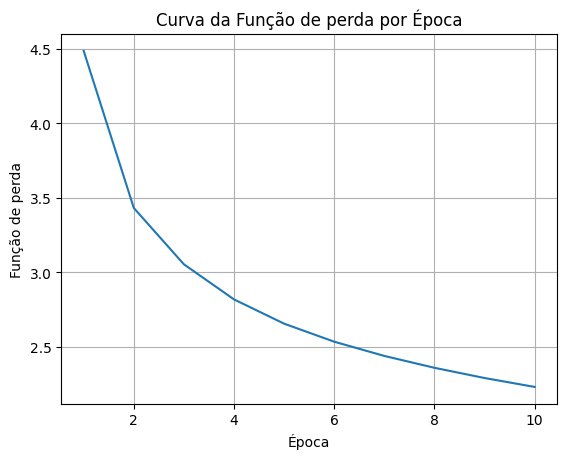

In [185]:
epochs = list(range(1, len(losses) + 1))
plt.figure()
plt.plot(epochs, losses)
plt.xlabel('Época')
plt.ylabel('Função de perda')
plt.title('Curva da Função de perda por Época')
plt.grid(True)
plt.show()

# 7. Geração de Texto

## Setup

In [186]:
# CLASSE TextGenerator – gera texto passo a passo com o modelo treinado
class TextGenerator:
    """
    Gera texto autoregressivamente com base num modelo treinado.

    Attributes
    ----------
    idx_to_word : list[str]
        Lista de mapeamento índice → palavra.
    word_to_idx : dict[str, int]
        Dicionário de mapeamento palavra → índice.
    default_temperature : float
        Temperatura padrão de amostragem.
    """

    def __init__(self, idx_to_word: list[str], temperature: float = 1.0):
        self.idx_to_word = idx_to_word                                  # mapeamento índice → palavra
        self.word_to_idx = {w: i for i, w in enumerate(idx_to_word)}    # dicionário inverso palavra → índice
        self.default_temperature = temperature                          # temperatura padrão de amostragem

    def _tokenize(self, txt: str) -> list[str]:
        """
        Converte texto cru em lista de tokens:
        - converte em letras minúsculas
        - aplica espaçamento em pontuação
        - divide em tokens por espaços

        Parameters
        ----------
        txt : str
            Texto de entrada.

        Returns
        -------
        list[str]
            Lista de tokens.
        """
        return pad_punctuation(txt.lower()).split()

    def _sample(self, probs: torch.Tensor, temperature: float) -> int:
        """
        Sorteia 1 token a partir de uma distribuição de probabilidade com temperatura.
        """
        probs = (probs ** (1 / temperature))        # aplica temperatura (↑temp = distribuição mais "uniforme")
        probs = probs / probs.sum()                 # re-normaliza para somar 1
        return torch.multinomial(probs, 1).item()   # amostra 1 índice segundo a distribuição ajustada

    @torch.no_grad()                                # desliga gradiente (inferência)
    def generate(
        self,
        model,                                      # modelo MiniGPT
        prompt: str,                                # texto inicial
        max_tokens: int = MAX_LEN,                  # comprimento máximo total
        temperature: float | None = None            # temperatura opcional por chamada
    ) -> list[dict]:                                # devolve lista de dicionários com stats de cada passo
        """
        Gera texto passo a passo e coleta estatísticas de atenção e distribuição.
        """

        model.eval()        # ativa modo de avaliação (desliga dropout, batchnorm, etc.)

        temp = self.default_temperature if temperature is None else temperature     # decide temperatura
        ids = [self.word_to_idx.get(t, 1) for t in self._tokenize(prompt)]          # prompt → lista de índices (1=<unk>)

        info: list[dict] = []                               # lista onde cada item = stats de um passo
        while len(ids) < max_tokens and ids[-1] != 0:       # pára ao atingir o tamanho máximo ou o token <pad>
            x = torch.tensor([ids], device=DEVICE)          # cria batch (1, S) e move p/ DEVICE
            log_probs, attn = model(x)                      # forward: obtém log_probs (1, S, V) e pesos de atenção

            # Extrai os pesos de atenção da última posição, isto é, do token que acabou de ser gerado (posição final). attn pode ser 3D ou 4D.
            if attn.ndim == 4:                                          # saída (B, heads, S, S) caso average_attn_weights = False
                step_atts = attn[0, :, -1, :].cpu().numpy()             # pega [batch=0, todas as cabeças, token alvo=-1, todas as posições de contexto]
            else:                                                       # saída (batch, S, S) caso average_attn_weights = True
                step_atts = attn[0, -1, :].unsqueeze(0).cpu().numpy()   # pega [batch=0, token alvo=-1, todas as posições de contexto], e recria uma dimensão de "heads"=1

            # Amostra o próximo token com temperatura
            probs = log_probs[0, -1].exp()                    # converte log-probabilidades → probabilidades
            next_id = self._sample(probs, temp)               # sorteia índice

            # Armazena informações do passo atual para posterior visualização
            info.append({
                "prompt": prompt,                   # texto gerado até antes de acrescentar next_id
                "word_probs": probs.cpu().numpy(),  # vetor de probabilidades p/ próximo token
                "atts": step_atts                   # mapa de atenção (heads, S)
            })

            ids.append(next_id)                         # adiciona token sorteado ao contexto
            prompt += " " + self.idx_to_word[next_id]   # concatena palavra ao texto exibido

        # Exibe o resultado completo
        print("Texto gerado:")
        display(prompt)

        return info                            # devolve lista com stats de todos os passos

In [187]:
def print_probs(info, vocab, top_k: int = 5):
    """
    Exibe:
      • frase gerada com realce de atenção (HTML)
      • top-k palavras mais prováveis no passo atual
    Parâmetros
    ----------
    info  : list[dict]  lista produzida por TextGenerator.generate()
    vocab : list[str]   mapeamento índice → palavra
    top_k : int         quantas palavras mostrar no ranking de probabilidades
    """
    for i in info:                                                   # percorre cada passo de geração
        highlighted_text = []                                        # armazenará o texto com cores de atenção


        # 1) gera HTML que colore cada palavra conforme o score de atenção
        for word, att_score in zip(
            i["prompt"].split(),                                     # palavras já geradas
            np.mean(i["atts"], axis=0)                               # atenção média da palavra alvo
        ):
            highlighted_text.append(                                 # cria um <span> colorido p/ cada palavra
                '<span style="background-color:rgba(135,206,250,'    # cor: azul-claro com alfa variável
                + str(att_score / max(np.mean(i["atts"], axis=0)))   # → normaliza pelo máx. do vetor
                + ');">'
                + word                                               # texto da palavra
                + "</span>"
            )

        highlighted_text = " ".join(highlighted_text)                # junta spans em uma string HTML
        display(HTML(highlighted_text))                              # mostra no notebook


        # 2) imprime top-k probabilidades da próxima palavra
        word_probs = i["word_probs"]                                 # vetor de probabilidades (float32, len = V)
        p_sorted = np.sort(word_probs)[::-1][:top_k]                 # top-k valores decrescentes
        i_sorted = np.argsort(word_probs)[::-1][:top_k]              # índices correspondentes

        for p, idx in zip(p_sorted, i_sorted):                       # percorre pares (prob, índice)
            print(f"{vocab[idx]}:\t{np.round(100 * p, 2)}%")         # exibe palavra e probabilidade %
        print("--------\n")                                          # linha separadora

## Gen

In [188]:
# Instancia o gerador de texto
text_generator = TextGenerator(vocab)

In [189]:
info = text_generator.generate(model, "recipe for roasted vegetables |", max_tokens=15, temperature=0.1)

Texto gerado:


'recipe for roasted vegetables | preheat oven to 350°f . butter and flour a 9'

In [190]:
info = text_generator.generate(model, "recipe for roasted vegetables |", max_tokens=15, temperature=0.5)

Texto gerado:


'recipe for roasted vegetables | preheat oven to 350°f . butter and flour a 9'

In [191]:
info = text_generator.generate(model, "recipe for roasted vegetables |", max_tokens=15, temperature=1)

Texto gerado:


'recipe for roasted vegetables | place passover rack in center of oven ; preheat to'

In [192]:
info = text_generator.generate(model, "recipe for roasted vegetables |", max_tokens=15, temperature=1.5)
print_probs(info, vocab)

Texto gerado:


'recipe for roasted vegetables | preheat the [UNK] pie crust with blueberries and blueberries .'

preheat:	33.459999084472656%
in:	10.510000228881836%
heat:	5.570000171661377%
combine:	4.940000057220459%
cut:	4.269999980926514%
--------



oven:	91.0%
broiler:	4.630000114440918%
the:	4.090000152587891%
a:	0.07999999821186066%
burners:	0.019999999552965164%
--------



oven:	99.0199966430664%
broiler:	0.5799999833106995%
rack:	0.05999999865889549%
large:	0.019999999552965164%
baking:	0.009999999776482582%
--------



...

with:	23.610000610351562%
and:	14.850000381469727%
.:	10.510000228881836%
|:	8.380000114440918%
on:	7.679999828338623%
--------



rack:	37.310001373291016%
the:	11.029999732971191%
a:	5.940000057220459%
nonstick:	4.099999904632568%
oil:	2.200000047683716%
--------



,:	30.06999969482422%
and:	28.899999618530273%
in:	24.729999542236328%
.:	6.480000019073486%
-:	2.319999933242798%
--------



cheese:	4.760000228881836%
candied:	4.349999904632568%
dried:	2.859999895095825%
mint:	2.819999933242798%
salt:	2.809999942779541%
--------



.:	50.47999954223633%
in:	19.489999771118164%
|:	7.420000076293945%
,:	7.059999942779541%
and:	4.570000171661377%
--------



# Avaliação

In [174]:
def compute_perplexity(model, data_loader):
    """
    Calcula a perplexidade de um modelo auto-regressivo em um conjunto de dados.

    A função percorre todos os lotes do data_loader, acumula a soma do NLL
    sobre todos os tokens não-PAD e, ao final, computa:

        avg_nll = NLL média por token
        perplexity = exp(avg_nll)

    Parameters
    ----------
    model : torch.nn.Module
        Modelo já treinado que recebe tensores [B, S] e retorna
        log-probabilidades [B, S, V] (além de pesos de atenção, se aplicável).
    data_loader : torch.utils.data.DataLoader
        DataLoader com lotes (x_batch, y_batch) usados para avaliação.

    Returns
    -------
    tuple of float
        avg_nll : NLL média por token não-PAD.
        ppl     : perplexidade correspondente (exp(avg_nll)).
    """

    model.eval()                                               # coloca o modelo em modo de avaliação
    total_loss = torch.tensor(0.0, device=DEVICE)              # acumula a soma da NLL sobre todos os tokens não-PAD
    total_tokens = torch.tensor(0.0, device=DEVICE)            # acumula o número total de tokens não-PAD usados no cálculo

    loss_fn = nn.NLLLoss(ignore_index=0,                       # NLLLoss ignorando o token <PAD> (ID 0), já que o modelo retorna log-probabilidades
                         reduction="sum")                      # reduction="sum": retorna a soma da NLL sobre os tokens válidos do lote

    with torch.no_grad():                                      # bloco sem cálculo de gradiente (apenas avaliação)
        for x_batch, y_batch in data_loader:                   # percorre todos os lotes (x, y) do data_loader
            x_batch = x_batch.to(DEVICE)                       # move o lote de entradas para o dispositivo
            y_batch = y_batch.to(DEVICE)                       # move o lote de alvos para o dispositivo

            log_probs, _ = model(x_batch)                      # obtém log-probabilidades do modelo: [B, S, V]

            loss = compute_nll_logprobs(                       # NLL somada sobre todos os tokens não-PAD do lote (escalares)
                log_probs,
                y_batch,
                loss_fn
            )

            total_loss += loss                                 # acumula a soma das perdas de todos os lotes
            total_tokens += (y_batch != 0).sum()               # acumula quantos tokens não são <PAD> (ID 0) em todo o data_loader

    avg_nll = total_loss / total_tokens                        # NLL média por token não-PAD em todo o conjunto avaliado
    ppl = torch.exp(avg_nll)                                   # perplexidade = exp(NLL média por token)

    return avg_nll.item(), ppl.item()                          # devolve valores escalares em float (para impressão / logging)

In [194]:
test_nll_gpt, test_ppl_gpt = compute_perplexity(model, test_dl)
print(f"MiniGPT NLL: {test_nll_gpt:.4f}, MiniGPT PPL: {test_ppl_gpt:.2f}")

MiniGPT NLL: 2.4519, MiniGPT PPL: 11.61


# Tarefa
- Treinar um modelo MiniGPT com a base de dados [Epicurious - Recipes with Rating and Nutrition](https://www.kaggle.com/datasets/hugodarwood/epirecipes) utilizada no laboratório 13:

  - `[TAREFA]_lab_13_ARMs_RNN.ipynb`.

- Experimentar com os hiperparâmetros do bloco transformer (e redimensionar se necessário para essa base de dados)
- Gere dados sintéticos variando a temperatura (ex. 0.1, 0.5, 1.0, 1.5)
- Comparar como os resultados obtidos laboratório 13 com as redes neurais recorrentes (utilizando *perplexity*).

**Entregáveis**:
1. Notebook `.ipynb`
2. Relatório `.pdf`